In [1]:
import sqlite3

# Connect to SQLite database (this will create the file if it doesn't exist)
conn = sqlite3.connect("sales_data.db")

# Create a cursor object
cursor = conn.cursor()

# Create sales table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert sample data
sales_data = [
    ("Laptop", 5, 50000),
    ("Mouse", 20, 500),
    ("Keyboard", 15, 1000),
    ("Laptop", 3, 52000),
    ("Mouse", 10, 450),
    ("Keyboard", 5, 950)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)

# Save changes
conn.commit()

print("Database and table created successfully!")

Database and table created successfully!


In [2]:
import pandas as pd

# SQL Query
query = """
SELECT 
    product,
    SUM(quantity) AS total_quantity,
    SUM(quantity * price) AS total_revenue
FROM sales
GROUP BY product
"""

# Load SQL result into pandas DataFrame
df = pd.read_sql_query(query, conn)

# Print the result
print("\nSales Summary:")
print(df)


Sales Summary:
    product  total_quantity  total_revenue
0  Keyboard              20        19750.0
1    Laptop               8       406000.0
2     Mouse              30        14500.0


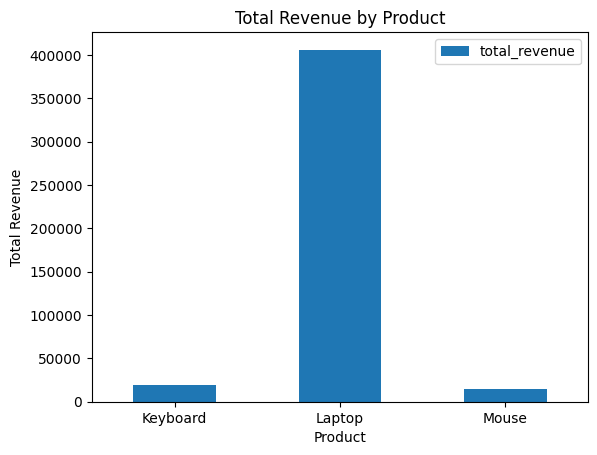

In [3]:
import matplotlib.pyplot as plt

# Create bar chart
df.plot(kind='bar', x='product', y='total_revenue')

plt.title("Total Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

# Save chart
plt.savefig("sales_chart.png")

# Show chart
plt.show()

In [4]:
conn.close()
print("Connection closed.")

Connection closed.
